# **Блок 1. Выбор датасета**


## Создание датасета

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.spatial.distance import cosine
import pandas as pd
import time

df = pd.read_csv("Iris.csv")

# **Блок 2. Первичный анализ данных**

## Вывод первых 5 строк

In [2]:
print('Первые 5 строк датасета')
df.head()

Первые 5 строк датасета


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Информация о датасете

In [3]:
print('Информация о датасете')
df.info()

Информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


## Размеры датасета

In [4]:
print('Размеры датасета')
df.shape

Размеры датасета


(150, 6)

## Проверка на наличие пустых ячеек

In [5]:
print('Количество пустых ячеек по столбцам')
misses = df.isnull().sum()
print(misses)

Количество пустых ячеек по столбцам
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


## Расспределение классов

In [6]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## Базовые статистики

In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# **Блок 3. Подготовка данных**

## Обработка пропусков не требуется, категориальных признаков нет.

## Разделение на test/train

In [8]:
X = df.drop(['Species','Id'], axis = 1)
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Масшатибирование признаков

In [9]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)


# **Почему масштабирование признаков важно для KNN?**

## KNN работает на основе расстояния между точками, возьмем формулу евклидового расстояния: d = sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}. Пусть x - возраст, а y - доход. Доход кратно больше возраста и будет иметь больший вес. Чтобы избежать этого используется масштабирование признаков.
### Наблюдение: в нашем случае масштабирование не сыграло большой роли(даже сделали предсказания хуже) потомучто признаки не сильно отличаются друг от друга


# **Почему нельзя подбирать параметры на тестовой выборке?**

## KNN нельзя давать доступ к тестовым данным, потому что она начнет подстраиваться под них и будет давать завышенную точность, а на новых тестовых данных покажет результат ниже ожидаемого

# **Блок 4-5. Обучение KNN и подбор гиперпараметров**

## Создание словаря гиперпараметров. Обучение модели

In [10]:
knn = KNeighborsClassifier()
grid = {
    'n_neighbors' : [1, 2, 3, 5, 7, 9],
    'metric' : ['euclidean', 'manhattan'],
    'weights' : ['uniform', 'distance']
}

grid_search = GridSearchCV(knn, grid, cv = 5, scoring = 'accuracy')
grid_search.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

## Вывод 10 лучших результатов

In [11]:
results = pd.DataFrame(grid_search.cv_results_)
top = results.nlargest(10, 'mean_test_score')[['params', 'mean_test_score']]

for i, row in top.iterrows():
    print(f"{row['params']} - {row['mean_test_score']:.4f}")

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'} - 0.9583
{'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'} - 0.9583
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'} - 0.9583
{'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'} - 0.9583
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'} - 0.9500
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'} - 0.9500
{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'} - 0.9500


## Исследование влияния гиперпараметров на точность

## Влияние гиперпараметра "Количество соседей"

In [12]:
k_results = results.groupby('param_n_neighbors')['mean_test_score'].mean()

for k,score in k_results.items():
    print(f"k={k} - {score:.4f}")

k=1 - 0.9375
k=2 - 0.9292
k=3 - 0.9437
k=5 - 0.9458
k=7 - 0.9500
k=9 - 0.9542


## Влияние гиперпараметра "метрика"

In [13]:
metrics_results = results.groupby('param_metric')['mean_test_score'].mean()

for m, score in metrics_results.items():
    print(f"{m} - {score:.4f}")

euclidean - 0.9444
manhattan - 0.9424


## Влияние гиперпараметра "weights"

In [14]:
weights_results = results.groupby('param_weights')['mean_test_score'].mean()

for w, score in weights_results.items():
    print(f"w={w} - {score:.4f}")

w=distance - 0.9472
w=uniform - 0.9396


# **Обучение модели без масшатабирования параметров**

In [15]:
knnNoM = KNeighborsClassifier()
grid_search_2 = GridSearchCV(knnNoM, grid, cv = 5, scoring = 'accuracy')
grid_search_2.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

## Вывод 10 лучших результатов

In [16]:
results2 = pd.DataFrame(grid_search_2.cv_results_)
top2 = results2.nlargest(10, 'mean_test_score')

for i, row in top2.iterrows():
    print(f"{row['params']} - {row['mean_test_score']:.4f}")

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'} - 0.9583
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} - 0.9583
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'} - 0.9583
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} - 0.9583
{'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'uniform'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 1, 'weights': 'distance'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'uniform'} - 0.9500
{'metric': 'euclidean', 'n_neighbors': 2, 'weights': 'distance'} - 0.9500
{'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'} - 0.9500
{'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'distance'} - 0.9500


## Влияние гиперпараметров

In [17]:
print('Количество соседей')

k_results_2 = results2.groupby('param_n_neighbors')['mean_test_score'].mean()
for k, score in k_results_2.items():
    print(f"k={k} - {score:.4f}")

Количество соседей
k=1 - 0.9500
k=2 - 0.9437
k=3 - 0.9583
k=5 - 0.9417
k=7 - 0.9417
k=9 - 0.9417


In [18]:
print('Метрика')

metrics_results_2 = results2.groupby('param_metric')['mean_test_score'].mean()
for m, score in metrics_results_2.items():
    print(f"m={m} - {score:.4f}")

Метрика
m=euclidean - 0.9465
m=manhattan - 0.9458


In [19]:
print('Веса')

weights_results_2 = results2.groupby('param_weights')['mean_test_score'].mean()
for w, score in weights_results_2.items():
    print(f"w={w} - {score:.4f}")

Веса
w=distance - 0.9472
w=uniform - 0.9451


# **Графики и сравнения**

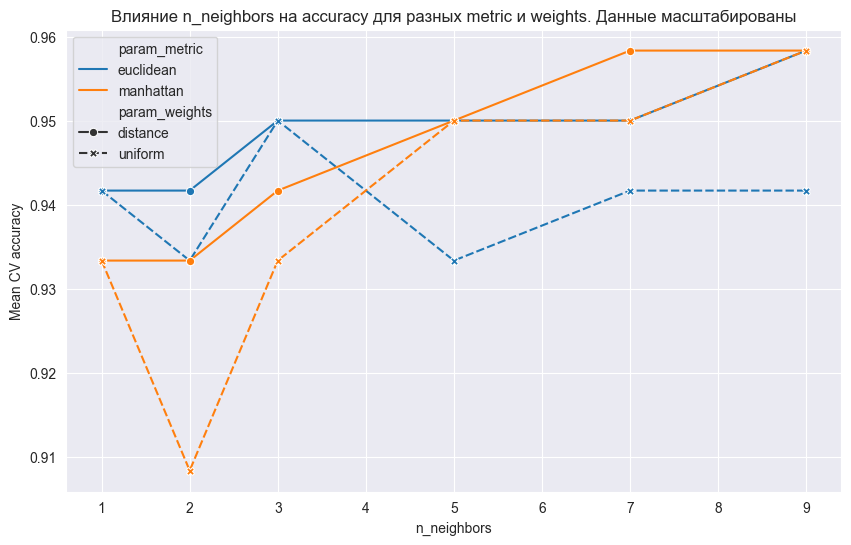

In [20]:
plot_data = results.groupby(['param_n_neighbors', 'param_metric', 'param_weights'], as_index=False)['mean_test_score'].mean()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_data,
    x='param_n_neighbors',
    y='mean_test_score',
    hue='param_metric',
    style='param_weights',
    markers=True,
    dashes=True,
    errorbar=None
)

plt.title('Влияние n_neighbors на accuracy для разных metric и weights. Данные масштабированы')
plt.xlabel('n_neighbors')
plt.ylabel('Mean CV accuracy')
plt.grid(True)
plt.show()

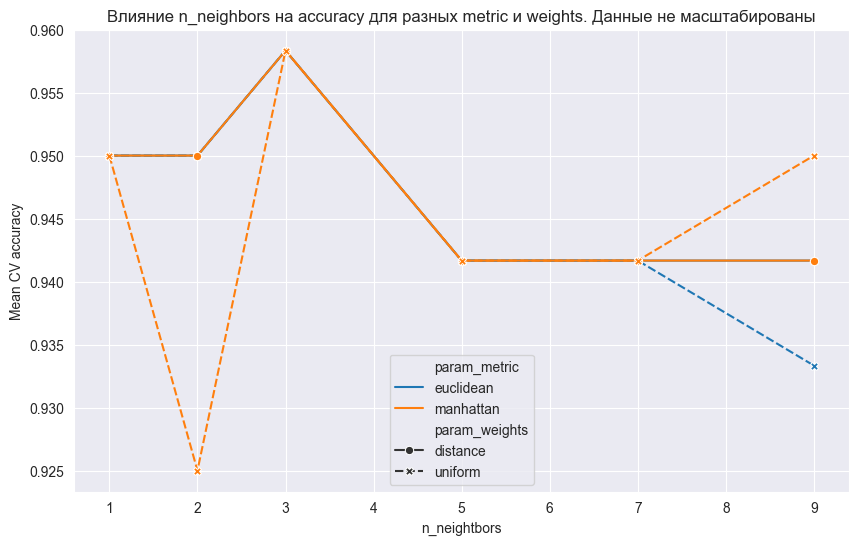

In [21]:
plot_data_2 = results2.groupby(['param_n_neighbors', 'param_metric', 'param_weights'], as_index=False)['mean_test_score'].mean()

plt.figure(figsize = (10,6))

sns.lineplot(
    data=plot_data_2,
    x='param_n_neighbors',
    y='mean_test_score',
    hue='param_metric',
    style='param_weights',
    markers=True,
    dashes=True,
    errorbar=None
)

plt.title('Влияние n_neighbors на accuracy для разных metric и weights. Данные не масштабированы')
plt.xlabel('n_neightbors')
plt.ylabel('Mean CV accuracy')
plt.grid(True)
plt.show()

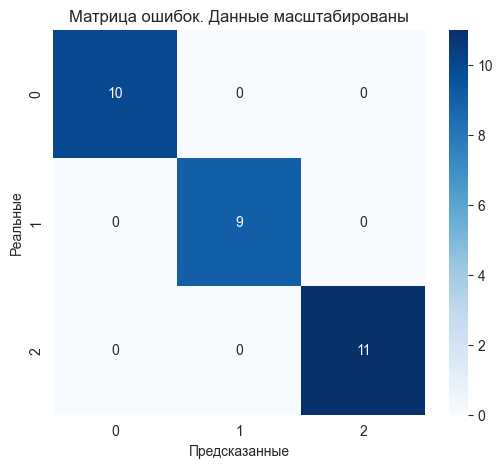

In [22]:
from sklearn.metrics import confusion_matrix

y_pred = grid_search.predict(x_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Предсказанные")
plt.ylabel("Реальные")
plt.title("Матрица ошибок. Данные масштабированы")

plt.show()

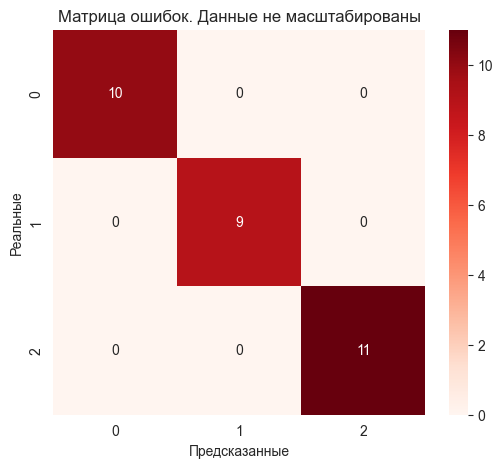

In [23]:
y_pred_2 = grid_search_2.predict(X_test)

cm2 = confusion_matrix(y_test, y_pred_2)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Reds"
)

plt.xlabel("Предсказанные")
plt.ylabel("Реальные")
plt.title("Матрица ошибок. Данные не масштабированы")

plt.show()

# **Выводы:**

## Модель KNN была обучена и были получены разные точности в зависимости от масштабирования/нет данных, количества соседей, выбора метрики(евклидова, манхеттонская), веса точки(учитывая расстояние/нет). Самая лучшая точность: 0.9583. Рассмотрено влияние гиперпараметров. Изображены графики с иллюстрацией средней точности в зависимости от параметров. Для моделей были представлены графики ошибок.